In [2]:
%pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

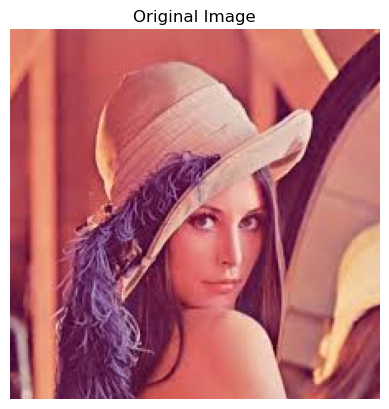

In [4]:
img = cv2.imread('lenna_color (3).jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

In [5]:
src = np.float32([
[0, 0],
[w-1, 0],
[0, h-1]
])


Affine Matrix (Translation):
 [[ 1.  0. 50.]
 [ 0.  1. 30.]]


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

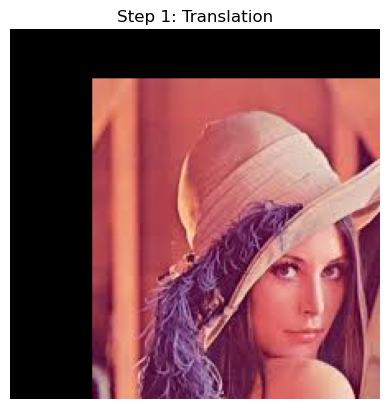

In [6]:
# Translation
tx, ty = 50, 30

dst_translate = np.float32([
[tx, ty],
[w-1+tx, ty],
[tx, h-1+ty]
])

M1 = cv2.getAffineTransform(src, dst_translate)

print("\nAffine Matrix (Translation):\n", M1)

img1 = cv2.warpAffine(img, M1, (w, h))

plt.imshow(img1)
plt.title("Step 1: Translation")
plt.axis("off")


Affine Matrix (Rotation):
 [[  0.86602538  -0.50000002  71.00515747]
 [  0.50000002   0.8660254  -40.99484634]]


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

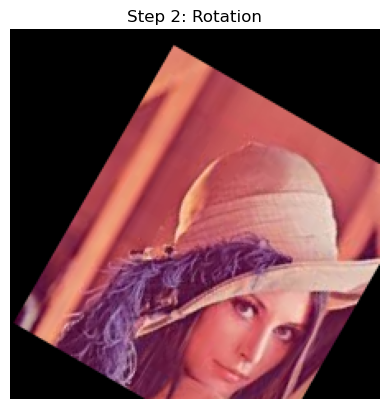

In [7]:
# Rotation
angle = np.deg2rad(30)

cx, cy = w//2, h//2

def rotate_point(x, y):
    xr = (x-cx)*np.cos(angle) - (y-cy)*np.sin(angle) + cx
    yr = (x-cx)*np.sin(angle) + (y-cy)*np.cos(angle) + cy
    return [xr, yr]

dst_rotate = np.float32([
rotate_point(0, 0),
rotate_point(w-1, 0),
rotate_point(0, h-1)
])

M2 = cv2.getAffineTransform(src, dst_rotate)

print("\nAffine Matrix (Rotation):\n", M2)

img2 = cv2.warpAffine(img1, M2, (w, h))

plt.imshow(img2)
plt.title("Step 2: Rotation")
plt.axis("off")


Affine Matrix (Scaling):
 [[1.19999995 0.         0.        ]
 [0.         1.19999995 0.        ]]


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

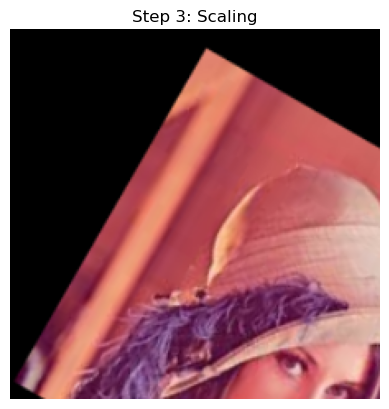

In [8]:
# Scaling
sx, sy = 1.2, 1.2

dst_scale = np.float32([
[0, 0],
[sx*(w-1), 0],
[0, sy*(h-1)]
])

M3 = cv2.getAffineTransform(src, dst_scale)

print("\nAffine Matrix (Scaling):\n", M3)

img3 = cv2.warpAffine(img2, M3, (w, h))

plt.imshow(img3)
plt.title("Step 3: Scaling")
plt.axis("off")

Affine Matrix (Reflection):
 [[ -1.   0. 224.]
 [  0.   1.   0.]]


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

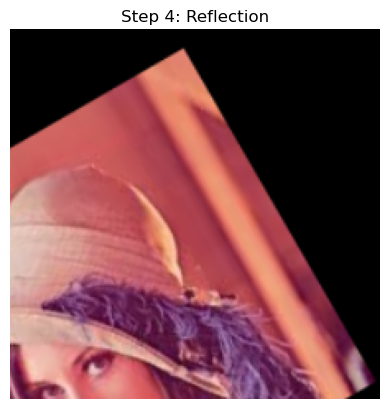

In [10]:
# Reflection
dst_reflect = np.float32([
[w-1, 0],
[0, 0],
[w-1, h-1]
])
M4 = cv2.getAffineTransform(src, dst_reflect)
img4 = cv2.warpAffine(img3, M4, (w, h))
print("Affine Matrix (Reflection):\n", M4)
plt.imshow(img4)
plt.title("Step 4: Reflection")
plt.axis("off")



Affine Matrix (Shearing):
 [[1.         0.         0.        ]
 [0.29999999 1.         0.        ]]


(np.float64(-0.5), np.float64(224.5), np.float64(224.5), np.float64(-0.5))

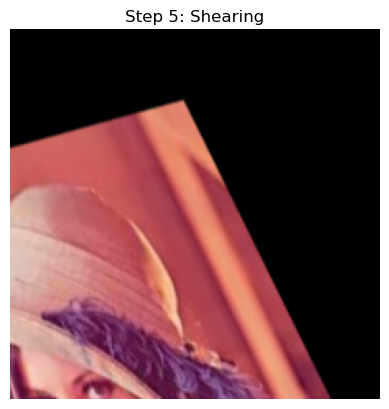

In [11]:
# Shearing
sh = 0.3

dst_shear = np.float32([
[0, 0],
[w-1, sh*(w-1)],
[0, h-1]
])

M5 = cv2.getAffineTransform(src, dst_shear)

print("\nAffine Matrix (Shearing):\n", M5)

img5 = cv2.warpAffine(img4, M5, (w, h))

plt.imshow(img5)
plt.title("Step 5: Shearing")
plt.axis("off")